In [1]:
#Packages
import pandas as pd
import numpy as np
import re
import os
import time
import torch
import transformers
import warnings
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import BertTokenizer, BertForSequenceClassification
warnings.filterwarnings("ignore", category=UserWarning)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Sentiment Extraction
def run_finbert(df, date_col='calendar_date', ticker_col='ticker',sec_col='section_type', role_col='role'):
  
    #Hardware Optimization for Local CPU
    torch.set_num_threads(max(1, os.cpu_count() - 1)) 
    
    #Pretrained Weights (Using ProsusAI/finbert standard mapping)
    model_name = "ProsusAI/finbert"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    model.eval()
    
    results_list = [] #Placeholder for appending results
    total_rows = len(df)
    start_time = time.time() #Measures time taken to execute
    
    #In-Memory Sequential Row Processing Loop
    for idx, (_, row) in enumerate(df.iterrows(), 1):
        text_input = str(row['finbert_input'])
        ticker = row.get(ticker_col, 'UNKNOWN')
        date_stamp = row.get(date_col, 'UNKNOWN')
        role = row.get(role_col, 'UNKNOWN')
        section_type = row.get(sec_col, 'UNKNOWN')
        
        # Tokenize
        inputs = tokenizer(
            text_input, 
            padding=True, 
            truncation=True, 
            max_length=512, 
            return_tensors="pt"
        )
        
        #DeactivateS gradient calculations to maintain low CPU memory footprints
        with torch.no_grad():
            outputs = model(**inputs)
            probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1).numpy()[0]
            
        pos_p = float(probabilities[0])
        neg_p = float(probabilities[1])
        neu_p = float(probabilities[2])
        net_score = pos_p - neg_p
        
        #Raw row metrics
        results_list.append({
            ticker_col: ticker,
            date_col: date_stamp,
            role_col: role,
            sec_col: section_type,
            'finbert_pos': pos_p,
            'finbert_neg': neg_p,
            'finbert_neu': neu_p,
            'finbert_net_score': net_score
        })
        
    print(f"\nInference loop successfully concluded in {time.time() - start_time:.2f} seconds.")
    
    #output DataFrame
    return pd.DataFrame(results_list)

In [3]:
#Cleaned Datasets
df_granular = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\Transcripts\FinBERT_Granular_Processed.csv")

In [4]:
df_granular.head(2)

,index,ticker,fiscal_year,fiscal_quarter,calendar_date,company_name,sector,section_type,speaker,role,turn_order,text,turn_word_count,transcript_total_words,finbert_input,finbert_input_len
0,1,ADSK,2020,Q1,2019-05-23,Autodesk Inc.,Information Technology,prepared_remarks,Abhey Lamba,executive,2,"Thanks, operator, and good afternoon. Thank yo...",233,10399,TITLE: ADSK Call - Abhey Lamba (executive) | S...,242
1,2,ADSK,2020,Q1,2019-05-23,Autodesk Inc.,Information Technology,prepared_remarks,Andrew Anagnost,executive,3,"Thanks, Abhey. We started off fiscal '20 with ...",213,10399,TITLE: ADSK Call - Andrew Anagnost (executive)...,222


In [5]:
#Set Hugging Face User Access Token to avoid access warning.
from getpass import getpass
os.environ["HF_TOKEN"] = getpass("Enter HF Token: ")

Enter HF Token:  ········


In [6]:
#Dataset Execution
granular_fin_sentiment = run_finbert(df_granular)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Inference loop successfully concluded in 4843.69 seconds.


In [7]:
#Sentimemt Dataset
granular_fin_sentiment.head(2)

,ticker,calendar_date,role,section_type,finbert_pos,finbert_neg,finbert_neu,finbert_net_score
0,ADSK,2019-05-23,executive,prepared_remarks,0.024386,0.032764,0.942850,-0.008378
1,ADSK,2019-05-23,executive,prepared_remarks,0.743809,0.012036,0.244154,0.731773


In [8]:
#Checking Data types and verifying no missing values 
sentiment_cols = ['finbert_pos','finbert_neg','finbert_neu','finbert_net_score']
print(granular_fin_sentiment[sentiment_cols].info())

<class 'pandas.DataFrame'>
RangeIndex: 13341 entries, 0 to 13340
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   finbert_pos        13341 non-null  float64
 1   finbert_neg        13341 non-null  float64
 2   finbert_neu        13341 non-null  float64
 3   finbert_net_score  13341 non-null  float64
dtypes: float64(4)
memory usage: 417.0 KB
None


In [9]:
#Range Validation
print("Net Sentiment Metric Summary Statistics")
display(granular_fin_sentiment['finbert_net_score'].describe().loc[['min', 'mean', 'max']])

Net Sentiment Metric Summary Statistics


min    -0.965802
mean    0.201467
max     0.944879
Name: finbert_net_score, dtype: float64

With net sentiment minimum being at -0.9 and maximum being at +0.9 proves that the data contains both highly negative events and highly positive updates.

In [10]:
#The Softmax Sum Unity Check
checksum = (granular_fin_sentiment['finbert_pos'] + granular_fin_sentiment['finbert_neg'] + granular_fin_sentiment['finbert_neu'])
is_unitary = np.allclose(checksum, 1.0, atol=1e-5)
print(f"Softmax Unity Audit Passed: {is_unitary}")

Softmax Unity Audit Passed: True


Because FinBERT utilizes a Softmax activation function on its final classification layer, the mathematical sum of the three output probabilities per row must equal exactly 1.0. From above audit, this is a success.

In [11]:
#The Zero-Sentiment Neutrality Check - Dataset A
#Calculate the percentage of rows where positive and negative are perfectly balanced (usually 0.0)
neutral_inertia_rate = (granular_fin_sentiment['finbert_net_score'] == 0.0).mean() * 100
print(f"Neutral Rate: {neutral_inertia_rate:.2f}% of the corpus is perfectly neutral.")

Neutral Rate: 0.00% of the corpus is perfectly neutral.


The above results proofs that the net sentiments have the needed variance to predict price movements.

### Visuals

In [12]:
#Core Styling Configurations
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11, 
    'axes.labelsize': 12, 
    'axes.titlesize': 14,
    'figure.titlesize': 16
})

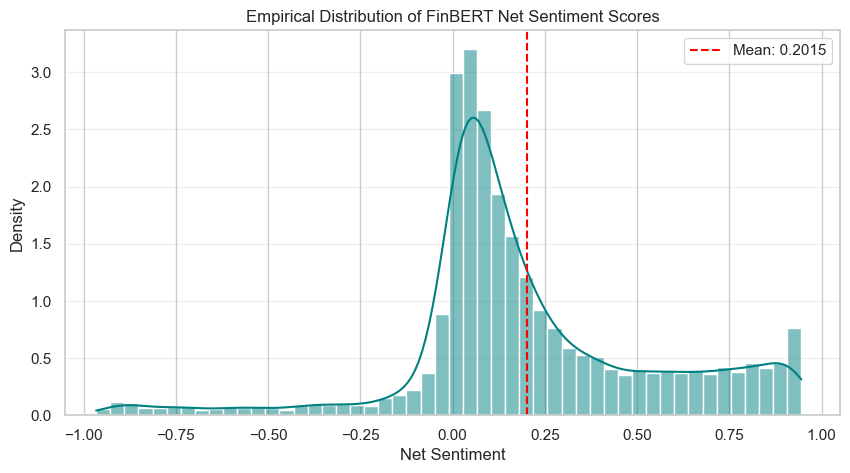

In [13]:
#The Empirical Distribution & Truncation Check (Histogram + KDE)
plt.figure(figsize=(10, 5))
#Plotting the distribution of the net score
sns.histplot(granular_fin_sentiment['finbert_net_score'], bins=50, kde=True, color='teal', stat='density')

#Adding a vertical line for the mean
plt.axvline(granular_fin_sentiment['finbert_net_score'].mean(), color='red', linestyle='--', 
            label=f"Mean: {granular_fin_sentiment['finbert_net_score'].mean():.4f}")

plt.title('Empirical Distribution of FinBERT Net Sentiment Scores', fontsize=12)
plt.xlabel('Net Sentiment')
plt.ylabel('Density')
plt.xlim(-1.05, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('Empirical Distribution ECT.png', dpi=300)
plt.show()

This plot above visualizes the distribution of the Net Scores across the theoretical [-1, +1] spectrum, overlaying a Kernel Density Estimate (KDE) and an explicit marker for the mean. This checks for a bimodal distribution vs. a normal distribution. We can see the net scores pile up around 0.0 (neutral news) but also positive.

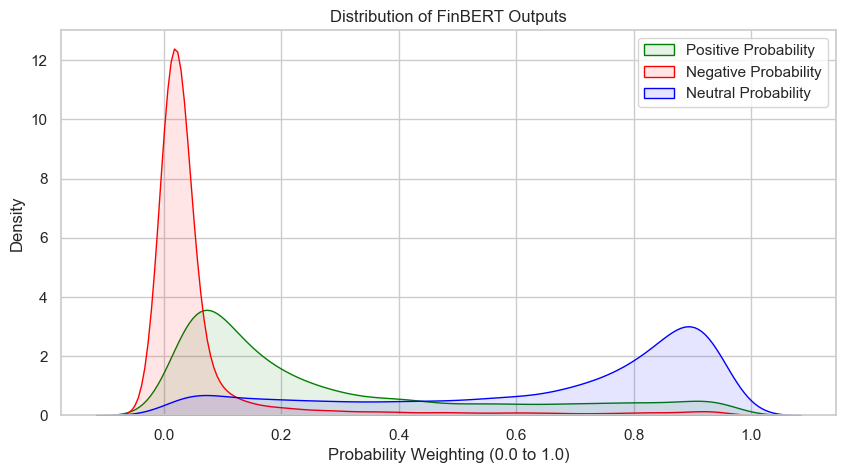

In [14]:
#The Softmax Tri-Axial Distribution (Density Plot)
plt.figure(figsize=(10, 5))
sns.kdeplot(granular_fin_sentiment['finbert_pos'], label='Positive Probability', color='green', fill=True, alpha=0.1)
sns.kdeplot(granular_fin_sentiment['finbert_neg'], label='Negative Probability', color='red', fill=True, alpha=0.1)
sns.kdeplot(granular_fin_sentiment['finbert_neu'], label='Neutral Probability', color='blue', fill=True, alpha=0.1)
plt.title('Distribution of FinBERT Outputs', fontsize=12)
plt.xlabel('Probability Weighting (0.0 to 1.0)')
plt.ylabel('Density')
plt.legend()
plt.savefig('Distribution of FinBERT Outputs-ECT.png', dpi=300)
plt.show()

The Softmax Tri-Axial Density Plot confirms the high parameter confidence of the classification head on the textual corpus. The probability distribution demonstrates an expected bi-modal behavior across the channels. In the low-probability spectrum (0.0 to 0.25), we observe a heavy concentration of density, indicating that when a definitive sentiment is detected, the probabilities of competing classes are successfully driven to zero.Conversely, in the high-confidence region (0.75 to 1.0), the model displays strong, unambiguous classification density for neutral factual sentences and negative risk disclosures, while extreme positive confidence displays a lower, more selective density profile. 

This plot unrolls your probability columns into a single coordinate layout to check the parameter confidence across your three output layers.When the model assigns a high score to positive/neutral, the negative head is mathematically forced down to a baseline near zero ($0.0$ to $0.2$). Across 12,000 rows, this creates a massive pile-up of low-value data points for the negative class. This explains why that curve shoots straight up at the bottom left of your chart: most sentences have a near-zero probability of being negative.

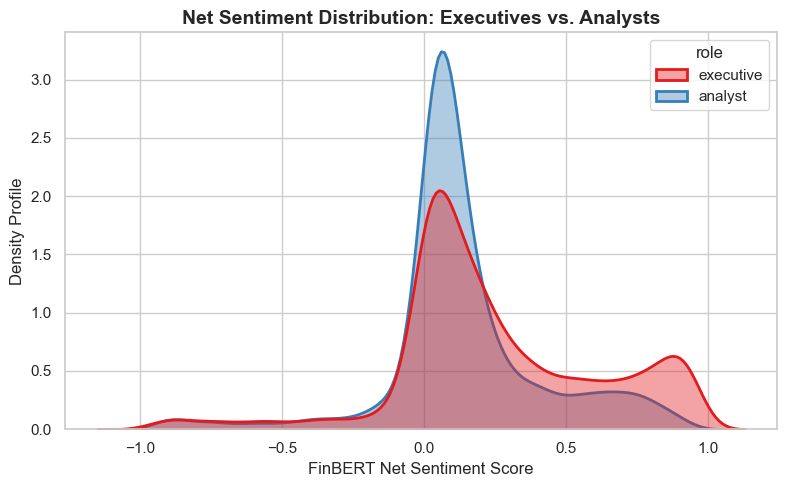

In [15]:
#Data
df = granular_fin_sentiment[granular_fin_sentiment['role'].str.lower().isin(['executive', 'analyst'])]
plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=df, 
    x='finbert_net_score', 
    hue='role', 
    fill=True, 
    common_norm=False, 
    palette='Set1', 
    alpha=0.4, 
    linewidth=2
)
plt.title('Net Sentiment Distribution: Executives vs. Analysts', fontweight='bold')
plt.xlabel('FinBERT Net Sentiment Score')
plt.ylabel('Density Profile')
plt.tight_layout()
plt.savefig('Net Sentiment Distribution-Roles.png', dpi=300)
plt.show()

This plot compares the continuous distribution profiles of Executives vs. Analysts to reveal behavioral differences in language.

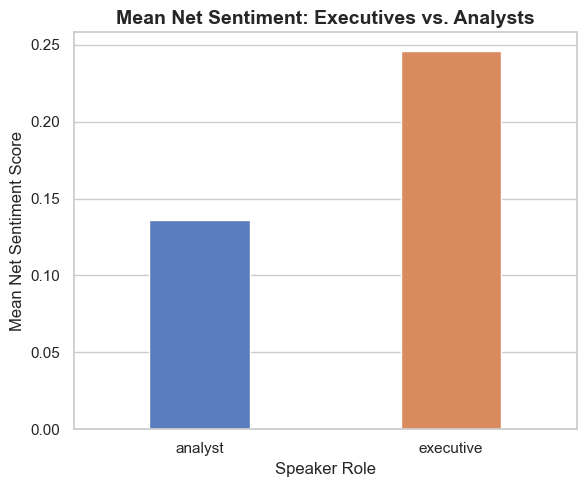

In [16]:
#Aggregate mean values for your two role types
role_summary = df.groupby('role')['finbert_net_score'].mean().reset_index()
plt.figure(figsize=(6, 5))
sns.barplot(
    data=role_summary, 
    x='role', 
    y='finbert_net_score', 
    hue='role',
    legend=False,
    palette='muted',
    width=0.4
)
plt.title('Mean Net Sentiment: Executives vs. Analysts', fontweight='bold')
plt.xlabel('Speaker Role')
plt.ylabel('Mean Net Sentiment Score')
plt.tight_layout()
plt.savefig('Mean Sentiments-Roles.png', dpi=300)
plt.show()

This bar chart calculates and renders the exact aggregate sentiment baseline ($\mu$) for each unique structural role inside the text data.

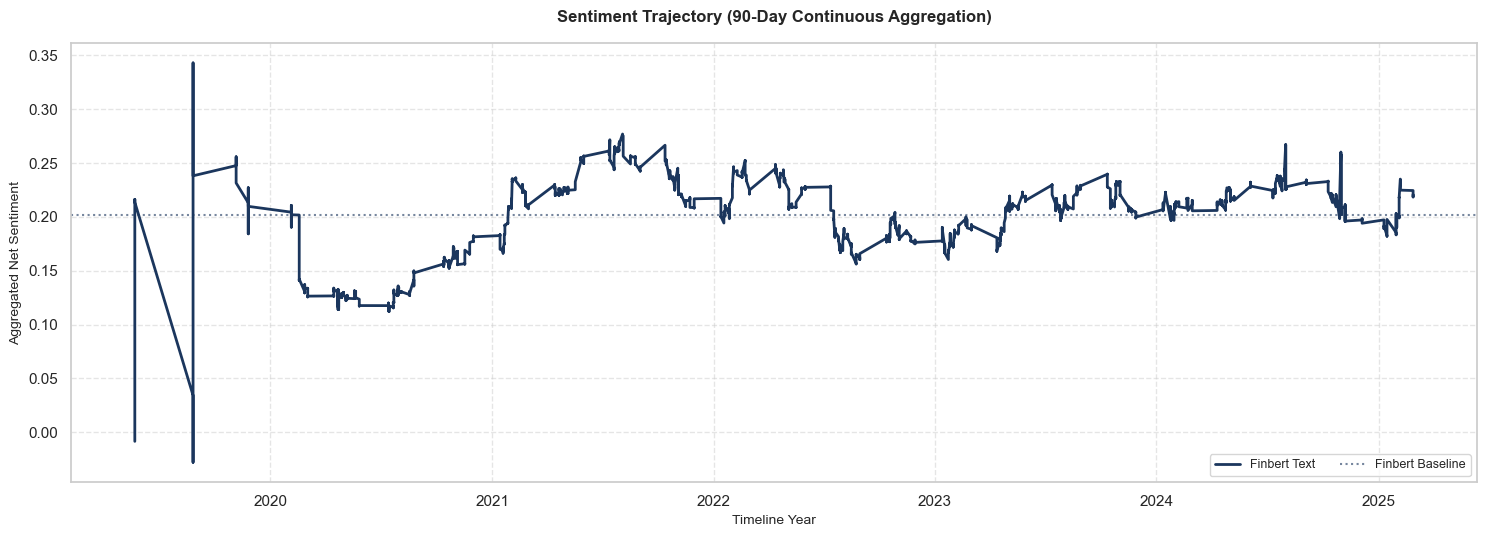

In [17]:
#Trajectory
time_df = granular_fin_sentiment[['calendar_date', 'finbert_net_score']].copy()
time_df['calendar_date'] = pd.to_datetime(time_df['calendar_date'])

#Sorting chronologically
time_df.sort_values('calendar_date', inplace=True)
time_df.set_index('calendar_date', inplace=True)

#Applying a 90-Day Continuous Rolling Mean min_periods=1 guards against empty weekend slots
rolling_sentiment = time_df.rolling(window='90D', min_periods=1).mean()

plt.rcParams['figure.figsize'] = (15, 5.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.plot(rolling_sentiment.index, rolling_sentiment['finbert_net_score'], label='Finbert Text', color='#1b365d', linewidth=2)
#Establishing the historical baselines (Means across the entire multi-year corpus)
plt.axhline(y=time_df['finbert_net_score'].mean(), color='#1b365d', linestyle=':', alpha=0.6, label='Finbert Baseline')

#Formatting
plt.title('Sentiment Trajectory (90-Day Continuous Aggregation)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Timeline Year', fontsize=10)
plt.ylabel('Aggregated Net Sentiment', fontsize=10)
plt.legend(loc='lower right', frameon=True, ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig('ECT_sentiment_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()

In [18]:
#Saving Data with Sentiment Scores
output_path1 = r'C:\Users\USER\PycharmProjects\ThesisProject\Data\Transcripts\Finbert_Sentiment_Score.csv'
granular_fin_sentiment.to_csv(output_path1, index=False)